In [1]:
import sys, os
sys.path.insert(0, '../utils')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from utils import load_neurons_table, load_synapses_position_transformed
from tqdm import tqdm
from connectome_types import CONNECTOME_SYN_TABLE_PATH, CONNECTOME_PRE_SYN_TABLE_PATH
from neuron_custom_features import calc_spines_features, calc_sk_length_in_column
from spines_utils import filter_valid_neuron_w_spines, split_syn_mat_by_type_four, generate_shuffles
from plot_utils import ex_color, inh_color, ei_palette
from scipy.stats import spearmanr
from connectome_types import SPINE_TABLE, SPINE_TABLE_OUTGOING
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
from stats_corr import p_to_stars, add_reg_line
from spine_pref_utils import per_neuron_spine_ratio, mean_input_outdegree
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
from figures_utils import add_panel_label
from scipy.stats import ks_2samp, mannwhitneyu
from matplotlib.ticker import FormatStrFormatter


In [3]:
filter_axon_pr = False # TODO; when this is on - it will move to a sup figure, dont touch for now

neurons_df = load_neurons_table() # raw table for subnetwork
syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_SYN_TABLE_PATH)
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
neuron_clf_type = df[['root_id', 'clf_type']].set_index('root_id').to_dict(orient='index')

if filter_axon_pr:
    from connectome_types import DATA_BASE_PATH
    pr_df = pd.read_csv(f'{DATA_BASE_PATH}/raw_tables/proofreading_status_and_strategy.csv', index_col=0)
    
    lvl = 'axon_partially_extended'
    # lvl = 'axon_fully_extended'
    fullax=pr_df[pr_df.strategy_axon == lvl].pt_root_id.tolist()
    df = df[df.root_id.isin(fullax)]
    print(f"Neurons in axon_pr subnetwork: {len(df)}")

df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)

spine_df_outgoing = pd.read_csv(SPINE_TABLE_OUTGOING)
outgoing_syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_PRE_SYN_TABLE_PATH)
outgoing_syn_with_tags = outgoing_syn_df[outgoing_syn_df.id_.isin(spine_df_outgoing.target_id)].copy()
outgoing_syn_with_tags['tag'] = outgoing_syn_with_tags.id_.map(spine_df_outgoing.set_index('target_id').tag)
print(f'neurons post: {outgoing_syn_with_tags.post_id.nunique()}')
print(f'neurons pre: {outgoing_syn_with_tags.pre_id.nunique()}')
print(f'outgoing synapses with tags: {outgoing_syn_with_tags.shape[0]}')

EE, EI, IE, II, ex_idx, inh_idx = split_syn_mat_by_type_four(filtered_bin_mat, filtered_mapping, neuron_clf_type)
print(f"Block shapes — EE:{EE.shape}  EI:{EI.shape}  IE:{IE.shape}  II:{II.shape}")

ex_syn_tags = syn_with_tags[syn_with_tags.pre_clf_type == 'E']
ee_syn_tags = ex_syn_tags[ex_syn_tags.post_clf_type == 'E']

inh_syn_tags = syn_with_tags[syn_with_tags.pre_clf_type == 'I']
ii_syn_tags = inh_syn_tags[inh_syn_tags.post_clf_type == 'I']

ex_neurons  = ex_neurons.copy()
inh_neurons = inh_neurons.copy()

connectome neurons table:  1351
valid neurons w position: 1351


spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)


neurons: 1351
synapses with tags: 145356


  0%|          | 0/1351 [00:00<?, ?it/s]

  0%|          | 4/1351 [00:00<00:35, 37.46it/s]

...

100%|█████████▉| 1346/1351 [00:37<00:00, 34.19it/s]

100%|█████████▉| 1350/1351 [00:37<00:00, 34.68it/s]

100%|██████████| 1351/1351 [00:37<00:00, 35.85it/s]

Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


neurons post: 49536
neurons pre: 1351
outgoing synapses with tags: 819823
Block shapes — EE:(1139, 1139)  EI:(1139, 159)  IE:(159, 1139)  II:(159, 159)


In [4]:
main_feature = 'spine'

root_ids  = ex_neurons.root_id.tolist()
ee_stats  = per_neuron_spine_ratio(ee_syn_tags,  root_ids)
e_all_stats = per_neuron_spine_ratio(ex_syn_tags,  root_ids)
# e_all_outside_stats = per_neuron_spine_ratio(spine_df_outgoing, root_ids, group_by='pre_pt_root_id')

ex_neurons[f'outgoing_{main_feature}_ratio_EE']  = ex_neurons.root_id.map(ee_stats['ratio'])
ex_neurons[f'outgoing_{main_feature}_ratio_all'] = ex_neurons.root_id.map(e_all_stats['ratio'])
# ex_neurons[f'outgoing_{main_feature}_ratio_all_outside'] = ex_neurons.root_id.map(e_all_outside_stats['ratio'])

# Get Data

In [5]:
REAL_BLOCKS = {'EE': EE, 'EI': EI, 'IE': IE, 'II': II}
BLOCK_COL_IDX = {
    'EE': ex_idx,
    'IE': ex_idx,
    'EI': inh_idx,
    'II': inh_idx,
}

all_idx = sorted(filtered_mapping.keys())
ex_od_df, inh_od_df = mean_input_outdegree(
    REAL_BLOCKS, BLOCK_COL_IDX, filtered_mapping, df,
    full_mat=filtered_bin_mat,
    all_idx=all_idx,
)

ex_neurons = ex_neurons.merge(
    ex_od_df[['root_id', 'mean_input_outdegree_EE', 'mean_input_outdegree_IE', 'mean_input_outdegree_full']],
    on='root_id', how='left'
)

inh_neurons = inh_neurons.merge(
    inh_od_df[['root_id', 'mean_input_outdegree_EI', 'mean_input_outdegree_II', 'mean_input_outdegree_full']],
    on='root_id', how='left'
)


In [6]:
calc_sk_length_in_column(ex_neurons)

Max x: 735.1817610250125, Min x: 604.9913590104155
Max z: 1023.8400000000003, Min z: 805.5600000000003


### Control

In [7]:
N_SHUFFLES = 100

shuffles_block = generate_shuffles(
    filtered_bin_mat, filtered_mapping, neuron_clf_type,
    amount=N_SHUFFLES, shuffle_preserve_EI=True
)

shuffles_regular = generate_shuffles(
    filtered_bin_mat, filtered_mapping, neuron_clf_type,
    amount=N_SHUFFLES, shuffle_preserve_EI=False
)

Shuffling [cfg]:   0%|          | 0/100 [00:00<?, ?it/s]

Shuffling [cfg]:   2%|▏         | 2/100 [00:00<00:09, 10.05it/s]

Shuffling [cfg]:   4%|▍         | 4/100 [00:00<00:09,  9.61it/s]

Shuffling [cfg]:   5%|▌         | 5/100 [00:00<00:10,  9.01it/s]

Shuffling [cfg]:   6%|▌         | 6/100 [00:00<00:10,  9.00it/s]

...

Shuffling [cfg]:  94%|█████████▍| 94/100 [00:05<00:00, 16.81it/s]

Shuffling [cfg]:  96%|█████████▌| 96/100 [00:05<00:00, 16.12it/s]

Shuffling [cfg]:  98%|█████████▊| 98/100 [00:05<00:00, 16.16it/s]

Shuffling [cfg]: 100%|██████████| 100/100 [00:05<00:00, 16.42it/s]

Shuffling [cfg]: 100%|██████████| 100/100 [00:05<00:00, 16.91it/s]

In [8]:
def add_sharing_prop_to_shuffles(shuffles):
    shuffled_ex_dfs = []
    shuffled_inh_dfs = []

    for shuffle in tqdm(shuffles):
        s_EE, s_EI, s_IE, s_II, s_ex_idx, s_inh_idx = split_syn_mat_by_type_four(shuffle, filtered_mapping, neuron_clf_type)

        shuffled_BLOCKS = {'EE': s_EE, 'EI': s_EI, 'IE': s_IE, 'II': s_II}
        shuffled_BLOCK_COL_IDX = {
            'EE': s_ex_idx,    
            'IE': s_ex_idx,   
            'EI': s_inh_idx,   
            'II': s_inh_idx,
        }

        all_idx = sorted(filtered_mapping.keys())
        s_ex_df, s_inh_df = mean_input_outdegree(
            shuffled_BLOCKS, shuffled_BLOCK_COL_IDX, filtered_mapping, df,
            full_mat=shuffle,
            all_idx=all_idx,
        )
        shuffled_ex_dfs.append(s_ex_df)
        shuffled_inh_dfs.append(s_inh_df)

    return shuffled_ex_dfs, shuffled_inh_dfs

shuffled_blocked_ex_dfs, shuffled_blocked_inh_dfs = add_sharing_prop_to_shuffles(shuffles_block)
shuffled_regular_ex_dfs, shuffled_regular_inh_dfs = add_sharing_prop_to_shuffles(shuffles_regular)

  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:00<00:10,  9.63it/s]

  2%|▏         | 2/100 [00:00<00:10,  9.71it/s]

  4%|▍         | 4/100 [00:00<00:09,  9.94it/s]

  5%|▌         | 5/100 [00:00<00:09,  9.61it/s]

...

 94%|█████████▍| 94/100 [00:08<00:00, 10.57it/s]

 96%|█████████▌| 96/100 [00:09<00:00, 10.41it/s]

 98%|█████████▊| 98/100 [00:09<00:00, 10.31it/s]

100%|██████████| 100/100 [00:09<00:00, 10.43it/s]

100%|██████████| 100/100 [00:09<00:00, 10.47it/s]

In [9]:
# e_control_full = [val for df in shuffled_regular_ex_dfs for val in df['mean_input_outdegree_full']]
# i_control_full = [val for df in shuffled_regular_inh_dfs for val in df['mean_input_outdegree_full']]

e_control_full = [val for df in shuffled_blocked_ex_dfs for val in df['mean_input_outdegree_full']]
i_control_full = [val for df in shuffled_blocked_inh_dfs for val in df['mean_input_outdegree_full']]

e_control_block = [val for df in shuffled_blocked_ex_dfs for val in df['mean_input_outdegree_EE']]
i_control_block = [val for df in shuffled_blocked_inh_dfs for val in df['mean_input_outdegree_II']]


def clean_data(data):
    if isinstance(data, pd.Series):
        return data.dropna().values
    return np.array([x for x in data if not np.isnan(x)])

def get_sig_marker(p_val, marker_type='star'):
    if p_val < 0.001:
        return '***' if marker_type == 'star' else '†††'
    elif p_val < 0.01:
        return '**' if marker_type == 'star' else '††'
    elif p_val < 0.05:
        return '*' if marker_type == 'star' else '†'
    return 'ns'

comparisons = [
    # Top Plot Comparisons
    ("E (Real) vs. I (Real)", 
     ex_od_df['mean_input_outdegree_full'], 
     inh_od_df['mean_input_outdegree_full'], 
     'star'),
     
    ("E (Real) vs. E (Control)", 
     ex_od_df['mean_input_outdegree_full'], 
     e_control_full, 
     'dagger'),

    ("I (Real) vs. I (Control)", 
     inh_od_df['mean_input_outdegree_full'], 
     i_control_full, 
     'dagger'),

]

print("=" * 60)
print(" STATISTICAL TEST RESULTS (Two-Sided)")
print("=" * 60)

for test_name, data1, data2, marker_type in comparisons:
    # Clean the data arrays
    d1 = clean_data(data1)
    d2 = clean_data(data2)
    
    # Run the tests
    ks_stat, ks_p = ks_2samp(d1, d2)
    mw_stat, mw_p = mannwhitneyu(d1, d2, alternative='two-sided')
    
    # Get significance markers based on p-value
    ks_sig = get_sig_marker(ks_p, marker_type)
    mw_sig = get_sig_marker(mw_p, marker_type)
    
    # Print the formatted logs
    print(f"\n➤ {test_name}")
    print(f"  [Kolmogorov-Smirnov Test]")
    print(f"    • Statistic : {ks_stat:.4f}")
    print(f"    • p-value   : {ks_p:.4e}  ({ks_sig})")
    
    print(f"  [Mann-Whitney U Test]")
    print(f"    • Statistic : {mw_stat:.4f}")
    print(f"    • p-value   : {mw_p:.4e}  ({mw_sig})")
    print("-" * 60)

 STATISTICAL TEST RESULTS (Two-Sided)

➤ E (Real) vs. I (Real)
  [Kolmogorov-Smirnov Test]
    • Statistic : 0.5528
    • p-value   : 3.0952e-40  (***)
  [Mann-Whitney U Test]
    • Statistic : 152850.5000
    • p-value   : 5.7643e-45  (***)
------------------------------------------------------------



➤ E (Real) vs. E (Control)
  [Kolmogorov-Smirnov Test]
    • Statistic : 0.3403
    • p-value   : 4.1253e-117  (†††)
  [Mann-Whitney U Test]
    • Statistic : 79821874.0000
    • p-value   : 5.2313e-41  (†††)
------------------------------------------------------------

➤ I (Real) vs. I (Control)
  [Kolmogorov-Smirnov Test]
    • Statistic : 0.2462
    • p-value   : 7.2066e-09  (†††)
  [Mann-Whitney U Test]
    • Statistic : 1437175.5000
    • p-value   : 2.9172e-03  (††)
------------------------------------------------------------


# Plot

In [10]:
plt.rcParams['font.size'] = 16
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['font.family'] = 'Arial'

reg_text_font_size = 12
featues_small_font_size = 12

sharing_prop_label = "Shared input strength/neuron\n(mean out-degree of all presynaptic neurons)"
sharing_prop_label_short = "Shared input strength"
scatter_use_sharing_z = False

spiny_color =  '#7C3AED' 
aspiny_color = '#059669'

if scatter_use_sharing_z:
    y_feature_all = 'z_mean_input_outdegree_full'
    y_feature_ee = 'z_mean_input_outdegree_EE'
    y_label = f"Z - {sharing_prop_label}"
else:
    y_feature_all = 'mean_input_outdegree_full'
    y_feature_ee = 'mean_input_outdegree_EE'
    y_label = sharing_prop_label

## all / full
use_ee = False
sharing_feature = y_feature_all
inh_sharing_feature = sharing_feature
spine_pref_feature = 'outgoing_spine_ratio_all'
e_control = e_control_full
i_control = i_control_full
dist_bins = np.arange(0, max(ex_od_df[f'{sharing_feature}'].max(), inh_od_df[f'{inh_sharing_feature}'].max()) + 40, 20)
e_label = 'E'
i_label = 'I'

# E-E and I-I # TODO; this is a sup. figure, dont change for now
# use_ee = True
# sharing_feature = y_feature_ee
# inh_sharing_feature = 'mean_input_outdegree_II'
# spine_pref_feature = 'outgoing_spine_ratio_EE'
# if not filter_axon_pr:
#     e_control = e_control_block
#     i_control = i_control_block
# dist_bins = np.arange(0, max(ex_od_df[f'{sharing_feature}'].max(), inh_od_df[f'{inh_sharing_feature}'].max()), 3)
# e_label = 'E-E'
# i_label = 'I-I'

In [11]:
def draw_network(ax, color_left='#d62728', color_right='#1f77b4', add_spines=False, shrink=0.7):
    """
    Draws a bipartite network graph, geometrically corrected for a tall subplot aspect ratio.
    """
    
    # ══════════════════════════════════════════════════════════════════════════════
    # CONFIGURATION
    # ══════════════════════════════════════════════════════════════════════════════
    COL_LEFT       = color_left  
    COL_RIGHT      = color_right 
    
    COL_PRE        = '#888888'
    COL_NET        = '#cccccc'
    COL_NET_EDGE   = '#aaaaaa'
    
    SZ_MAIN        = 24 * shrink
    SZ_PRE         = 15 * shrink
    SZ_NET         = 150 * shrink

    if add_spines:
        LW_INPUT_ARR   = 2
        LW_FAN_RIGHT   = 0.65
        LW_FAN_LEFT    = 0.98
        LW_SPINES      = 1.5
    else:
        LW_INPUT_ARR   = 2
        LW_FAN_RIGHT   = 0.65
        LW_FAN_LEFT    = 0.98
        LW_SPINES      = 0.0

    ALPHA_FAN_RIGHT= 0.55
    ALPHA_FAN_LEFT = 0.55

    # --- GEOMETRY CORRECTED COORDINATES ---
    
    # Centers of gravity (Pushed slightly inward to avoid edge clipping)
    offset = 0.225 * shrink
    C_LEFT  = np.array([0.50 - offset, 0.50])
    C_RIGHT = np.array([0.50 + offset, 0.50])
    
    # INNER RING (The 3 neighbors)
    # RY is smaller than RX to counteract the tall GridSpec, rendering a visual circle.
    RX_INNER = 0.12 * shrink       
    RY_INNER = 0.09 * shrink      

    # OUTER RING (The rest of the network)
    # Scaled to naturally fill the vertical whitespace without extreme distortion.
    RX_OUTER_MIN, RX_OUTER_MAX = 0.16 * shrink, 0.20 * shrink
    RY_OUTER_MIN, RY_OUTER_MAX = 0.2 * shrink, 0.3 * shrink

    # 4. Scale the Axis Limits (Maintains a tight crop around the shrunk drawing)
    x_reach = 0.46 * shrink  # Distance from center to the far left/right edges
    y_reach = 0.3 * shrink  # Distance from center to the top/bottom edges

    ax.set_xlim(0.50 - x_reach, 0.50 + x_reach)  
    ax.set_ylim(0.50 - y_reach, 0.50 + y_reach)
    ax.axis('off')

    # ── Main nodes ────────────────────────────────────────────────────────────────
    v_left  = C_LEFT
    v_right = C_RIGHT

    # ── Inner Ring (The 3 Neighbors) ──────────────────────────────────────────────
    # Distributed as a triangle (Top, Bottom-Right, Bottom-Left)
    angles_inner = np.array([np.pi/2, 7*np.pi/6, 11*np.pi/6])
    
    pre_left = [
        C_LEFT + np.array([RX_INNER * np.cos(a), RY_INNER * np.sin(a)]) for a in angles_inner
    ]
    pre_right = [
        C_RIGHT + np.array([RX_INNER * np.cos(a), RY_INNER * np.sin(a)]) for a in angles_inner
    ]
    
    Y_OFFSET_TOP = 0.04  # Change this number to push the top node higher or lower
    pre_left[0][1]  += Y_OFFSET_TOP
    pre_right[0][1] += Y_OFFSET_TOP

    # ── Outer Ring (The Rest of the Network) ──────────────────────────────────────
    def make_elliptical_cloud(center, rx_min, rx_max, ry_min, ry_max, n_nodes, seed=0):
        rng = np.random.RandomState(seed)
        rx = rng.uniform(rx_min, rx_max, n_nodes)
        ry = rng.uniform(ry_min, ry_max, n_nodes)
        # Evenly space them around 360 degrees, with random jitter
        theta = np.linspace(0, 2 * np.pi, n_nodes, endpoint=False) + rng.uniform(-0.15, 0.15, n_nodes)
        xs = center[0] + rx * np.cos(theta)
        ys = center[1] + ry * np.sin(theta)
        return np.column_stack((xs, ys))

    N_NODES = 8

    cloud_left  = make_elliptical_cloud(C_LEFT,  RX_OUTER_MIN, RX_OUTER_MAX, RY_OUTER_MIN, RY_OUTER_MAX, N_NODES, seed=42)
    cloud_right = make_elliptical_cloud(C_RIGHT, RX_OUTER_MIN, RX_OUTER_MAX, RY_OUTER_MIN, RY_OUTER_MAX, N_NODES, seed=42)

    n_left  = len(cloud_left)
    n_right = len(cloud_right)

    # ── Connectivity helpers ───────────────────────────────────────────────────────
    def distribute_sparse(n, n_groups, seed=0):
        rng = np.random.RandomState(seed)
        idx = list(range(n))
        rng.shuffle(idx)
        groups = [[] for _ in range(n_groups)]
        for i, v in enumerate(idx):
            groups[i % n_groups].append(v)
        return groups

    def distribute_dense(n, n_groups, k_per_group, seed=0):
        rng = np.random.RandomState(seed)
        groups = []
        for _ in range(n_groups):
            targets = rng.choice(n, size=k_per_group, replace=False).tolist()
            groups.append(targets)
        return groups

    left_conn  = distribute_dense(n_left, 3, k_per_group=8, seed=1)
    right_conn = distribute_sparse(n_right, 3, seed=2)

    # ── Arrow style helpers ────────────────────────────────────────────────────────
    def fan_props(col, lw, alpha):
        return dict(arrowstyle='-|>,head_length=0.55,head_width=0.3', color=col, lw=lw, alpha=alpha,
                    shrinkA=5, shrinkB=4, connectionstyle='arc3,rad=0.05')

    inp_props = dict(arrowstyle='->', shrinkA=int(SZ_PRE // 2 + 2), 
                     shrinkB=int(SZ_MAIN // 2 + 2), connectionstyle='arc3,rad=0.0')
                     
    def spine_props(col, lw, alpha):
            return dict(arrowstyle='->', color=col, lw=lw, alpha=alpha,
                        shrinkA=int(SZ_MAIN // 2 + 2), 
                        shrinkB=int(np.sqrt(SZ_NET) / 2), # Fixed math here to close the gap
                        connectionstyle='arc3,rad=0.05')

    # ── Draw fans: inner ring → outer ring ─────────────────────────────────────────
    for pre, targets in zip(pre_right, right_conn):
        for t in targets:
            ax.annotate('', xy=(cloud_right[t][0], cloud_right[t][1]), xytext=(pre[0], pre[1]),
                        arrowprops=fan_props(COL_PRE, LW_FAN_RIGHT, ALPHA_FAN_RIGHT), zorder=2)

    for pre, targets in zip(pre_left, left_conn):
        for t in targets:
            ax.annotate('', xy=(cloud_left[t][0], cloud_left[t][1]), xytext=(pre[0], pre[1]),
                        arrowprops=fan_props(COL_PRE, LW_FAN_LEFT, ALPHA_FAN_LEFT), zorder=2)

    # ── Draw NEW Spines: main → outer ring (if flag is True) ───────────────────────
    if add_spines:
        rng_spines = np.random.RandomState(99)

        purple_idx_right = rng_spines.randint(0, n_right)
        for t in range(n_right):
            edge_col = spiny_color if t == purple_idx_right else aspiny_color
            ax.annotate('', xy=(cloud_right[t][0], cloud_right[t][1]), xytext=(v_right[0], v_right[1]),
                        arrowprops=spine_props(edge_col, LW_SPINES, 0.85), zorder=2)

        for t in range(n_left):
            edge_col = spiny_color
            ax.annotate('', xy=(cloud_left[t][0], cloud_left[t][1]), xytext=(v_left[0], v_left[1]),
                        arrowprops=spine_props(edge_col, LW_SPINES, 0.85), zorder=2)

    # ── Draw outer ring nodes ──────────────────────────────────────────────────────
    ax.scatter(cloud_right[:,  0], cloud_right[:,  1], s=SZ_NET, color=COL_NET,
               edgecolors=COL_NET_EDGE, linewidths=0.5, zorder=3)
    ax.scatter(cloud_left[:, 0], cloud_left[:, 1], s=SZ_NET, color=COL_NET,
               edgecolors=COL_NET_EDGE, linewidths=0.5, zorder=3)

    # ── Draw input arrows: inner ring → main ──────────────────────────────────────
    props_right = dict(inp_props)
    props_right.update({'color': COL_RIGHT if not add_spines else 'gray', 'lw': LW_INPUT_ARR})
    for p in pre_right:
        ax.annotate('', xy=(v_right[0], v_right[1]), xytext=(p[0], p[1]),
                    arrowprops=props_right, zorder=5)

    props_left = dict(inp_props)
    props_left.update({'color': COL_LEFT if not add_spines else 'gray', 'lw': LW_INPUT_ARR})
    for p in pre_left:
        ax.annotate('', xy=(v_left[0], v_left[1]), xytext=(p[0], p[1]),
                    arrowprops=props_left, zorder=5)

    # ── Draw nodes ────────────────────────────────────────────────────────────────
    for p in pre_right + pre_left:
        ax.plot([p[0]], [p[1]], 'o', ms=SZ_PRE, color=COL_PRE, alpha=0.25, zorder=4)
        ax.plot([p[0]], [p[1]], 'o', ms=SZ_PRE, color='black', mfc='none', mew=1.25, zorder=4)

    for pos, col in [(v_right, COL_RIGHT), (v_left, COL_LEFT)]:
        ax.plot([pos[0]], [pos[1]], 'o', ms=SZ_MAIN, color='black', zorder=6, mew=1.5, mfc=col)
        
    return ax


In [12]:
cmap = plt.get_cmap("gray", 8)  # Reverse to have blue for the first feature and purple for the last

feature_color_master = {
    f'{sharing_feature}': cmap(4),  # '#1f77b4',
    f'{spine_pref_feature}': cmap(3),  # '#ff7f0e',
    'axon_local_path_length': cmap(4),  # '#2ca02c',
    'ds_spine_density': cmap(5), #"#FFE52A",  # '#d62728',
    'dendrite_local_path_length': cmap(6),  # '#9467bd'
}

feature_color_master = {
    f'{sharing_feature}': 'black',
    f'{spine_pref_feature}': spiny_color, #"#B71C1C",          # Dark Crimson (Output 2)
    'axon_local_path_length':spiny_color, # "#B71C1C",         # Vivid Rust (Output 1)
    'ds_spine_density': aspiny_color, # "#004D40",               # Deep Pine (Input 2)
    'dendrite_local_path_length':aspiny_color # "#004D40",     # Vibrant Deep Cyan (Input 1)
}

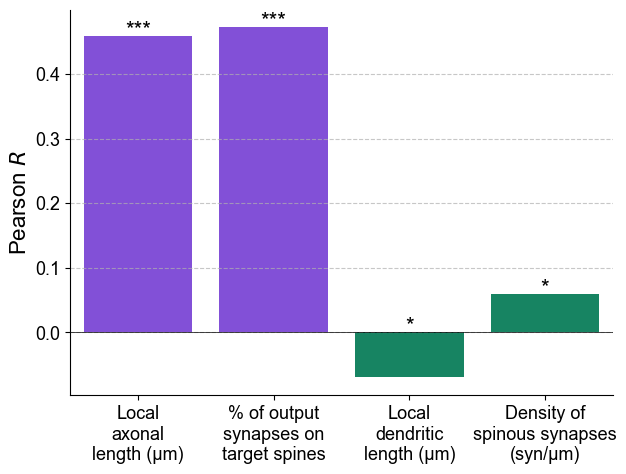

--- Pearson R / p-value summary ---
axon_local_path_length: R=0.459, p=1.693e-60 ***
outgoing_spine_ratio_all: R=0.473, p=1.940e-64 ***
dendrite_local_path_length: R=-0.070, p=1.888e-02 *
ds_spine_density: R=0.059, p=4.484e-02 *


In [13]:
x_features = ['axon_local_path_length', f'{spine_pref_feature}', 'dendrite_local_path_length', 'ds_spine_density']
x_feature_labels = ['Local\naxonal\nlength (μm)',
                    '% of output\nsynapses on\ntarget spines',
                    'Local\ndendritic\nlength (μm)',
                    'Density of\nspinous synapses\n(syn/μm)']
x_feature_labels2 = ['Local axonal length\n(μm)',
                     '% of output synapses on\ntarget spines',
                     'Local dendritic length\n(μm)',
                     'Density of spinous synapses\n(syn/μm)']

color_palette_bar_plot = {
    label: feature_color_master[feature] 
    for feature, label in zip(x_features, x_feature_labels)
}

pearson_corrs = []
pearson_p_vals = []
pearson_corr_p_vals_str = []
for x in x_features:
    valid_data = ex_neurons[[x, sharing_feature]].dropna()
    r, p_val = pearsonr(valid_data[x], valid_data[sharing_feature])
    pearson_corrs.append(r)
    pearson_p_vals.append(p_val)
    pearson_corr_p_vals_str.append(p_to_stars(p_val))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=x_feature_labels, y=pearson_corrs, ax=ax, palette=color_palette_bar_plot, hue=x_feature_labels, legend=False, alpha=1)
ax.set_ylabel('Pearson $R$')
ax.set_xticks(range(len(x_feature_labels)))
ax.set_xticklabels(x_feature_labels, fontsize=13)
ax.axhline(0, color='black', linewidth=0.5) # Add a baseline at 0
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.7)


for i, (corr, star) in enumerate(zip(pearson_corrs, pearson_corr_p_vals_str)):
    va = 'bottom' if corr >= 0 else 'top'
    offset = 0.025
    y = corr + offset if corr >= 0 else offset
    
    ax.text(
        x=i,               # Categorical x-axis positions are 0, 1, 2, etc.
        y=y,   # The height of the bar plus the offset
        s=star,            # The string from your array (e.g., '***')
        ha='center',       # Center the text horizontally over the bar
        va='top',             # Align text above or below the bar edge
        fontsize=16,       
        color='black'
    )

plt.show()

print('--- Pearson R / p-value summary ---')
for feat, r, p, star in zip(x_features, pearson_corrs, pearson_p_vals, pearson_corr_p_vals_str):
    print(f'{feat}: R={r:.3f}, p={p:.3e} {star}')


In [14]:
ex_neurons_sorted = ex_neurons.sort_values('cell_type')

ignore_cell_type = ['WM-P', 'Unsure E']
ex_neurons_sorted = ex_neurons_sorted[~ex_neurons_sorted['cell_type'].isin(ignore_cell_type)]
ex_neurons_sorted['cell_type'] = ex_neurons_sorted['cell_type'].cat.remove_unused_categories()

dist_features = x_features + [sharing_feature]
dist_feature_labels = [x.replace('\n', ' ') for x in x_feature_labels] + [sharing_prop_label_short]
dist_feature_labels = x_feature_labels2 + [sharing_prop_label_short]
label_map = dict(zip(dist_features, dist_feature_labels))

In [15]:
purples = ['#C4B5FD', '#A17EFC', '#7C3AED']
greens = ['#6EE7B7', '#34D399', '#10B981', '#059669', '#047857']

scatter_palette = {
    '23P': spiny_color,
    '4P': purples[1],
    '5P-IT': purples[0],
    '5P-NP': greens[4],
    '5P-PT': greens[3],
    '6P-CT': greens[2],
    '6P-IT': greens[1],
    '6P-U': greens[0],
}


def plot_feature_distributions(ax=None):
    df_norm = ex_neurons_sorted.copy()
    for col in dist_features:
        df_norm[col] = (df_norm[col] - df_norm[col].mean()) / df_norm[col].std()

    df_melt = df_norm.melt(id_vars=['cell_type'], value_vars=dist_features,
                           var_name='feature', value_name='z_score')
    df_melt['feature_label'] = df_melt['feature'].map(label_map)

    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 6), dpi=300)
        
    sns.boxplot(data=df_melt, x='feature_label', y='z_score', hue='cell_type', palette=scatter_palette, showfliers=True, ax=ax, width=0.6) 

    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylabel('Standardized Value (Z-score)')
    ax.set_xlabel('') 
    ax.legend(title='', loc='upper center', frameon=False, ncol=8, bbox_to_anchor=(0.5, 1.1))
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # --- LEGEND with cell types ---
    handles, labels = ax.get_legend_handles_labels()
    counts = ex_neurons_sorted.cell_type.value_counts()
    new_labels = [f"{label}\n(n={counts.get(label, 0)})" for label in labels]
    
    ax.legend(handles=handles, labels=new_labels, title='', loc='upper center', 
              frameon=False, ncol=8, bbox_to_anchor=(0.5, 1.1))

    # Add Means
    purple_group = ['23P', '4P', '5P-IT']
    green_group = ['5P-NP', '5P-PT', '6P-CT', '6P-IT', '6P-U']
    plotted_features = df_melt['feature_label'].unique()
    
    for i, feature in enumerate(plotted_features):
        feat_data = df_melt[df_melt['feature_label'] == feature]
        purple_mean = feat_data[feat_data['cell_type'].isin(purple_group)]['z_score'].mean()
        green_mean = feat_data[feat_data['cell_type'].isin(green_group)]['z_score'].mean()
        
        x_offset = 0.35
        ax.scatter([i+-x_offset], [purple_mean], color=spiny_color, edgecolor='gray', zorder=3, s=150, marker='*', alpha=0.8)
        ax.scatter([i+x_offset], [green_mean], color=aspiny_color, edgecolor='gray', zorder=3, s=150, marker='*', alpha=0.8)


    # Add colors to text labesl
    colors_texts = list(reversed(list(feature_color_master.values())))
    for i, tick_label in enumerate(ax.get_xticklabels()):
        tick_label.set_color(colors_texts[i])
        tick_label.set_fontweight('bold')

In [16]:
fig = plt.figure(figsize=(21, 16), dpi=600)
gs = fig.add_gridspec(9, 16, wspace=15, hspace=15)

# ==========================================
# ROW 1 (Top)
# ==========================================
# ax_A (3x6): Left side remains 6 columns wide
ax_A = fig.add_subplot(gs[0:3, 0:6])

# ax_B (3x10): Right side increased from 6 to 10 columns wide
ax_B = fig.add_subplot(gs[0:3, 6:16])

# ==========================================
# ROW 2 (Middle)
# ==========================================
# ax_C (3x6): Left side remains 6 columns wide
ax_C = fig.add_subplot(gs[3:6, 0:6])

# ax_D (3x5): Increased from 3 to 5 columns wide
ax_D = fig.add_subplot(gs[3:6, 6:11])

# ax_E (3x5): Increased from 3 to 5 columns wide
ax_E = fig.add_subplot(gs[3:6, 11:16])

# ==========================================
# ROW 3 (Bottom)
# ==========================================
# ax_F (3x16): Spans the full width of the 16 columns
ax_F = fig.add_subplot(gs[6:9, 0:16])

# A 
draw_network(ax_A, color_left=ex_color, color_right=inh_color, add_spines=False, shrink=0.7)
legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='E', markerfacecolor=ex_color, markersize=10),
        Line2D([0], [0], marker='o', color='w', label='I', markerfacecolor=inh_color, markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Neighbor', markerfacecolor='#e1e1e1', markeredgecolor='black', markeredgewidth=1.25, markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Peer neuron', markerfacecolor='#cccccc', markeredgecolor='#aaaaaa', markeredgewidth=0.5, markersize=10),
]
ax_A.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4, frameon=False)
ax_A.text(0.25, 0.05, 'High common input', ha='center', va='bottom', fontsize=featues_small_font_size, transform=ax_A.transAxes)
ax_A.text(0.75, 0.05, 'Low common input', ha='center', va='bottom', fontsize=featues_small_font_size, transform=ax_A.transAxes)

# B
shared_kwargs = dict(fill=True, alpha=0.15, stat='probability', element='step', linewidth=2.5)
control_kwargs = dict(fill=False, alpha=1, stat='probability', element='step', linestyle='--', linewidth=1.5)

sns.histplot(data=ex_od_df[f'{sharing_feature}'], bins=dist_bins, color=ex_color, label=f'{e_label} (Data)', ax=ax_B, **shared_kwargs)
sns.histplot(data=inh_od_df[f'{inh_sharing_feature}'], bins=dist_bins, color=inh_color, label=f'{i_label} (Data)', ax=ax_B, **shared_kwargs)
sns.histplot(data=e_control, bins=dist_bins, label=f'{e_label} (Control)', ax=ax_B, color=ex_color, **control_kwargs)
sns.histplot(data=i_control, bins=dist_bins, label=f'{i_label} (Control)', ax=ax_B, color=inh_color, **control_kwargs)
ax_B.set_ylabel('Probability')
ax_B.legend(frameon=False, loc='upper right')
ax_B.spines[["top", "right"]].set_visible(False)
ax_B.set_xlabel(sharing_prop_label)
ax_B.yaxis.set_major_formatter(FormatStrFormatter('%g'))


# C
draw_network(ax_C, color_left=ex_color, color_right=ex_color, add_spines=True, shrink=0.7)
legend_elements_c1 = [
    Line2D([0], [0], color=spiny_color, lw=0, marker=r'$\rightarrow$', markersize=18, label='spine'),
    Line2D([0], [0], color=aspiny_color, lw=0, marker=r'$\rightarrow$', markersize=18, label='shaft/soma'),
]
ax_C.legend(handles=legend_elements_c1, title='Synapse onto', 
             loc='upper center', bbox_to_anchor=(0.5, 1.2), 
             ncol=2, frameon=False, alignment='center')
ax_C.text(0.25, 0.05, 'High common input', ha='center', va='bottom', fontsize=featues_small_font_size, transform=ax_C.transAxes)
ax_C.text(0.75, 0.05, 'Low common input', ha='center', va='bottom', fontsize=featues_small_font_size, transform=ax_C.transAxes)


# D
sns.barplot(x=x_feature_labels, y=pearson_corrs, ax=ax_D, palette=color_palette_bar_plot, hue=x_feature_labels, legend=False)
ax_D.set_ylabel(f'Correlations with\n{sharing_prop_label_short.lower()}')
ax_D.set_xticks(range(len(x_feature_labels)))
ax_D.set_xticklabels(x_feature_labels, fontsize=featues_small_font_size)
ax_D.axhline(0, color='black', linewidth=0.5) # Add a baseline at 0
ax_D.spines[["top", "right"]].set_visible(False)
ax_D.grid(axis='y', linestyle='--', alpha=0.7)
ax_D.yaxis.set_major_formatter(FormatStrFormatter('%g'))

for i, (corr, star) in enumerate(zip(pearson_corrs, pearson_corr_p_vals_str)):
    va = 'bottom' if corr >= 0 else 'top'
    offset = 0.025
    y = corr + offset if corr >= 0 else offset
    
    ax_D.text(
        x=i,               # Categorical x-axis positions are 0, 1, 2, etc.
        y=y,   # The height of the bar plus the offset
        s=star,            # The string from your array (e.g., '***')
        ha='center',       # Center the text horizontally over the bar
        va='top',             # Align text above or below the bar edge
        fontsize=16,       
        color='black'
    )


# E
sns.scatterplot(data=ex_neurons_sorted, x=f'{spine_pref_feature}', y=sharing_feature, s=16, alpha=0.7,ax=ax_E,
                hue='cell_type', palette=scatter_palette, legend=True)
ax_E.legend(title='', loc='upper left', frameon=False, markerscale=1.5, fontsize=featues_small_font_size-1, ncol=1)
ax_E.set_ylabel(sharing_prop_label_short)
ax_E.set_xlabel('% of output synapses on\ntarget spines')
ax_E.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0, symbol=''))

# Add regression lines
add_reg_line(ex_neurons[f'{spine_pref_feature}'], ex_neurons[sharing_feature], 
             ax=ax_E, color='gray', reg_text_font_size=reg_text_font_size,
             linestyle='--', linewidth=1.2, add_reg_text='r_only')	 
ax_E.spines[["top", "right"]].set_visible(False)
ax_E.set_ylim(bottom=0)


# F
plot_feature_distributions(ax=ax_F)

fig.canvas.draw() 
delta1 = 0.04   # Amount to shift ax_A down
delta2 = 0.04  # Amount to shift ax_C down

pos_A = ax_A.get_position()
pos_C = ax_C.get_position()

ax_A.set_position([
    pos_A.x0,               # Keep horizontal position
    pos_A.y0 - delta1,      # Shift down
    pos_A.width,            # Keep original width
    pos_A.height            # Keep original height
])

ax_C.set_position([
    pos_C.x0,               # Keep horizontal position
    pos_C.y0 - delta2,      # Shift down
    pos_C.width,            # Keep original width
    pos_C.height            # Keep original height
])

# ==========================================
# --- Add all Panel Labels ---
# ==========================================
add_panel_label(ax_A, 'A', xy=(-0.01, 1.25))
add_panel_label(ax_B, 'B', xy=(-0.05, 1.05))
add_panel_label(ax_C, 'C', xy=(-0.01, 1.25))
add_panel_label(ax_D, 'D', xy=(-0.11, 1.05))
add_panel_label(ax_E, 'E', xy=(-0.05, 1.05))
add_panel_label(ax_F, 'F', xy=(-0.005, 1.05))

plt.savefig('fig4.pdf', format='pdf', bbox_inches='tight')


R=0.47 R^2: 0.22 slope: 189.72 intercept: 78.01, p=p=1.9e-64
